#### Imports

In [1]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

In [2]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

#### Path definition and file inspection

In [3]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


## Dataset loading and exploration

In [4]:
# load data
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
X_test = utils.load_test_csv(globals.CURRENT_TEST_FILE)

# inspect shapes
print("X:", X.shape)
print("Y:", Y.shape)
print("X_test:", X_test.shape)
wavelengths = wavelengths.squeeze()
print("wavelengths:", wavelengths.shape)

X: (500, 9)
Y: (500, 25230)
X_test: (10000, 9)
wavelengths: (4205,)


For each sample:
- Inputs: 9 physical parameters (aerosols, gases, geometry, etc.)
- Outputs: 6 different radiative quantities (25230 / 4205) each evaluated over 4205 wavelengths

#### Inputs Analysis

In [5]:
# print start of X
print("X (first 5 rows):\n", X[:5])
print()

# print basic stats of X
print("X stats:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("  mean:", X.mean(axis=0))
print("  std:", X.std(axis=0))
print()

# print basic stats of wavelengths
print("wavelengths stats:")
print("  min:", wavelengths.min())
print("  max:", wavelengths.max())
print("  average step:", np.diff(wavelengths).mean())

X (first 5 rows):
 [[  0.3277   3.1157   0.345    0.7131   0.5288   0.8954  19.7791   7.7608 108.5301]
 [  0.3934   1.9633   0.1254   0.6778   1.076    0.9024  13.9765   0.7065  57.5871]
 [  0.277    3.3399   0.3508   0.7798   0.5656   0.8813  22.8422   8.8415  86.0363]
 [  0.3872   2.9762   0.2018   0.6871   0.7028   0.895   41.9614   7.6079 102.0078]
 [  0.3122   3.1903   0.1551   0.7968   0.7071   0.8519  19.9584   1.0314 145.9431]]

X stats:
  min: [ 0.2503  0.701   0.1007  0.6002  0.5     0.8501 10.0422  0.0239  0.0474]
  max: [  0.3999   3.4994   0.4992   0.7997   1.6998   0.9498  59.9118  14.9793 179.9885]
  mean: [ 0.325   2.1     0.3     0.7     1.1     0.9    35.0001  7.4998 90.0019]
  std: [ 0.0433  0.8084  0.1155  0.0577  0.3464  0.0289 14.433   4.3303 51.9564]

wavelengths stats:
  min: 399.8400639744102
  max: 2506.2656641604012
  average step: 0.5010527117473813


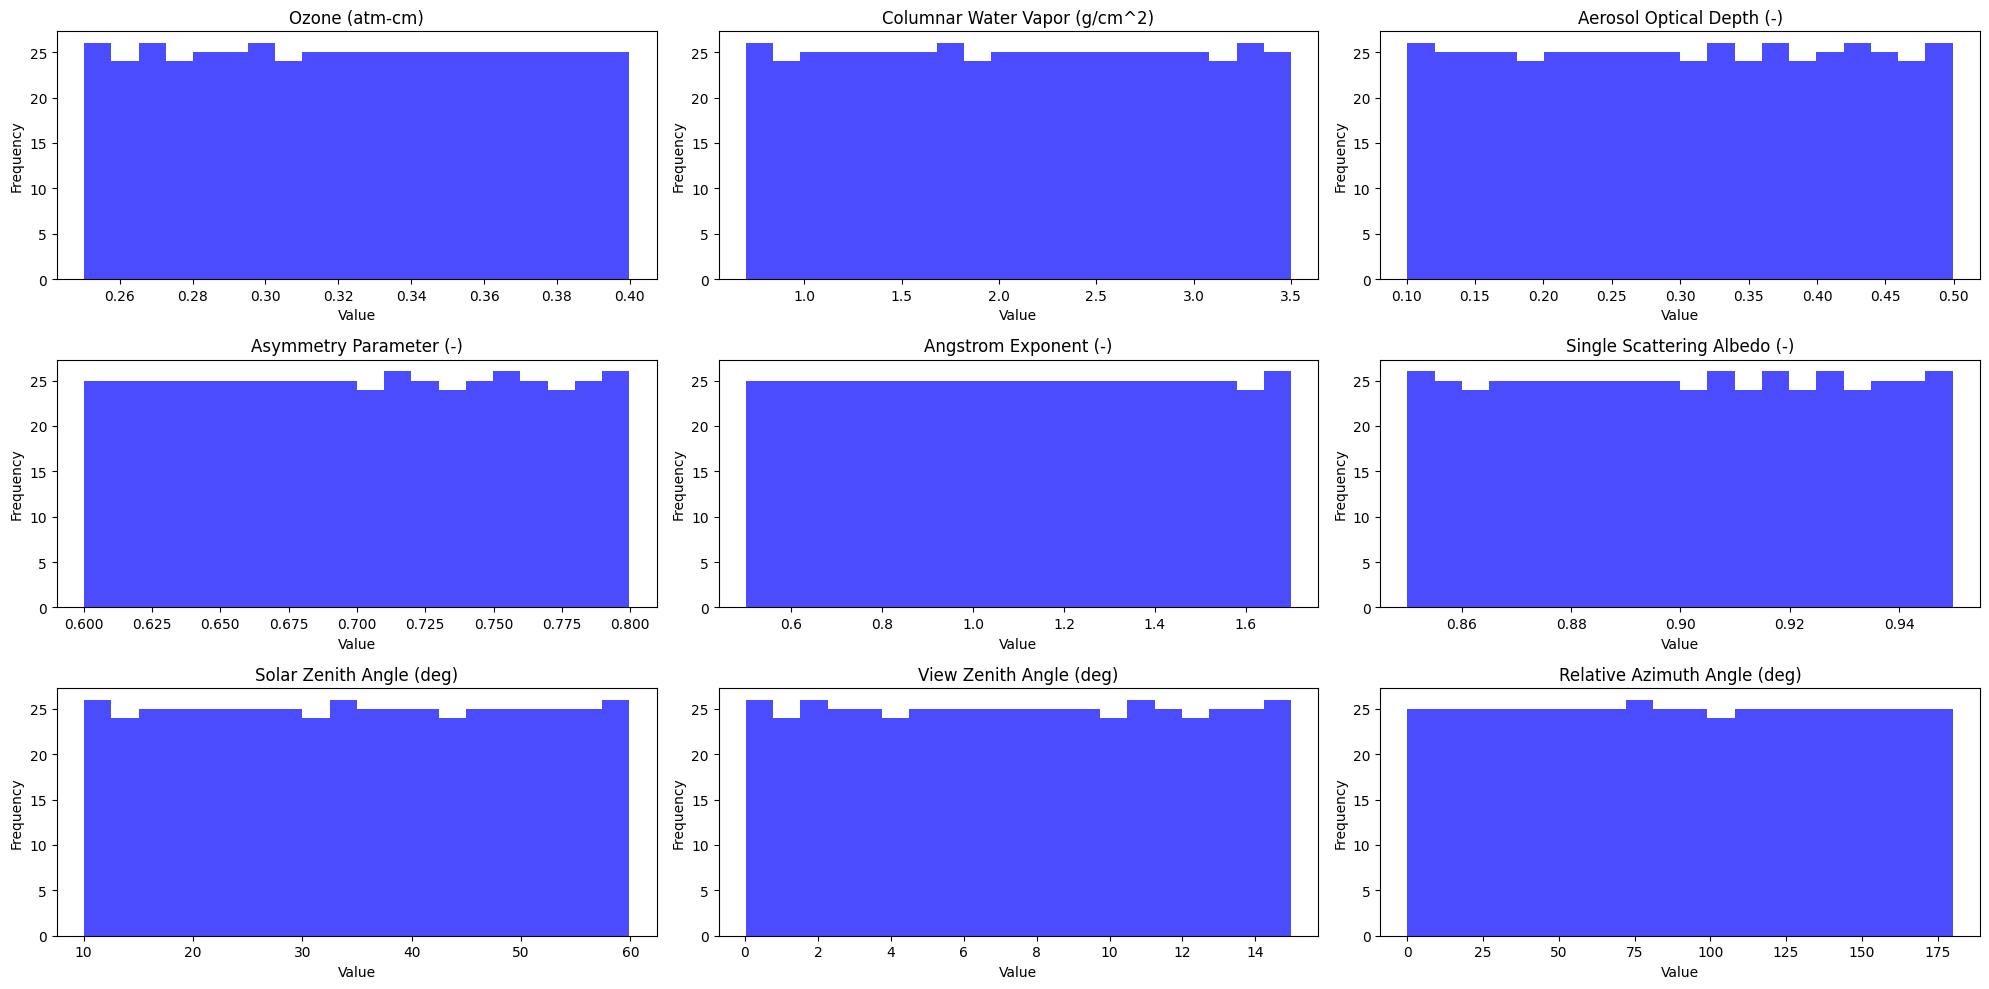

In [6]:
# visualize distribution of all 9 input parameters
plt.figure(figsize=(20, 10))
for i in range(globals.N_INPUTS):
    plt.subplot(3, 3, i+1)
    plt.hist(X[:, i], bins=20, color="blue", alpha=0.7)
    plt.title(globals.param_names_plots[i])
    plt.xlabel("Value")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

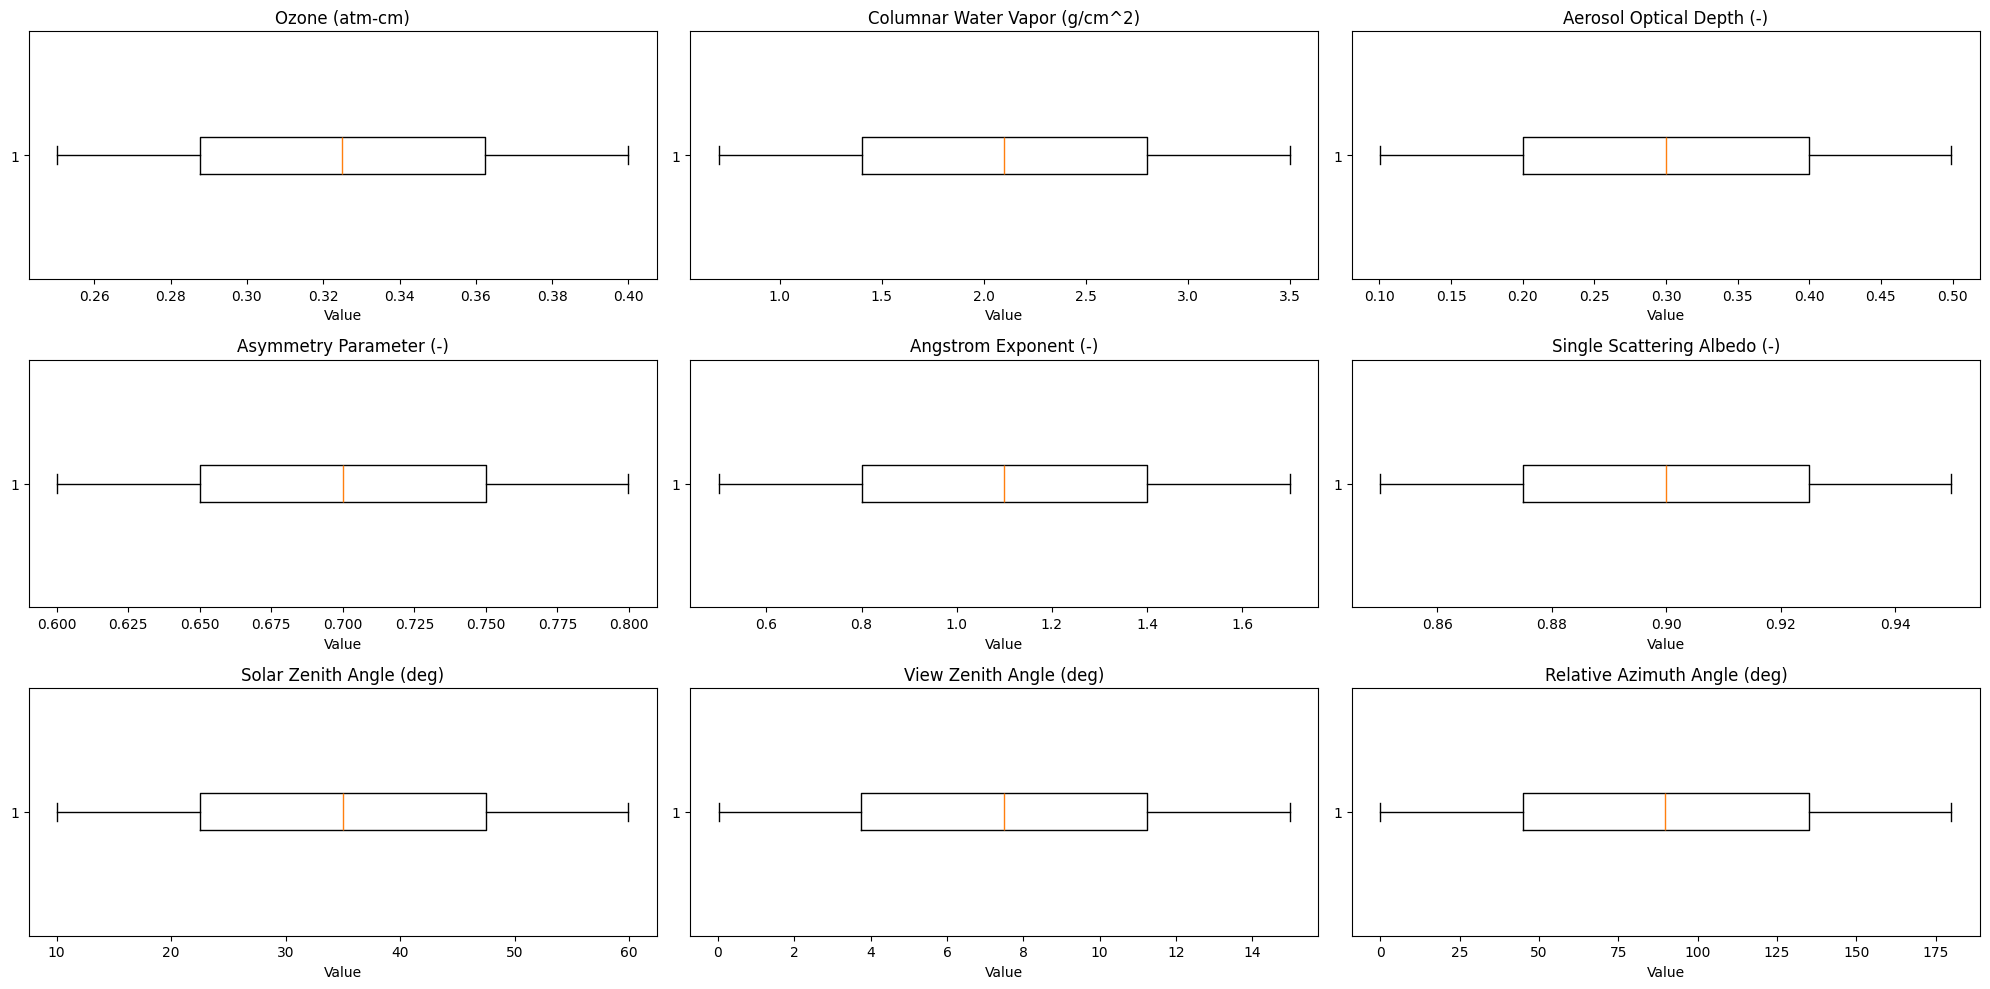

In [7]:
# detect potential outliers in the input parameters using boxplots
plt.figure(figsize=(20, 10))
for i in range(globals.N_INPUTS):
    plt.subplot(3, 3, i+1)
    plt.boxplot(X[:, i], vert=False)
    plt.title(globals.param_names_plots[i])
    plt.xlabel("Value")
plt.tight_layout()
plt.show()

As expected from the distributions shown above, no outliers can be seen in the dataset.

Correlation matrix:
                    O3       CWV       AOD  Asy. Param.  Ang. Exp.       SSA       SZA       VZA       RAA
O3           1.000000 -0.009808  0.017317    -0.028726  -0.004428  0.003923  0.039847  0.008036 -0.044014
CWV         -0.009808  1.000000  0.052001    -0.076699  -0.020032  0.039859 -0.007161  0.058809  0.033224
AOD          0.017317  0.052001  1.000000    -0.017497   0.092734  0.057227  0.005658 -0.016578 -0.043741
Asy. Param. -0.028726 -0.076699 -0.017497     1.000000  -0.020244  0.065476  0.044121  0.004497  0.010482
Ang. Exp.   -0.004428 -0.020032  0.092734    -0.020244   1.000000  0.016107  0.072337 -0.026959 -0.093277
SSA          0.003923  0.039859  0.057227     0.065476   0.016107  1.000000 -0.013776  0.021112  0.047424
SZA          0.039847 -0.007161  0.005658     0.044121   0.072337 -0.013776  1.000000  0.044679 -0.065723
VZA          0.008036  0.058809 -0.016578     0.004497  -0.026959  0.021112  0.044679  1.000000 -0.036335
RAA         -0.044014  0.

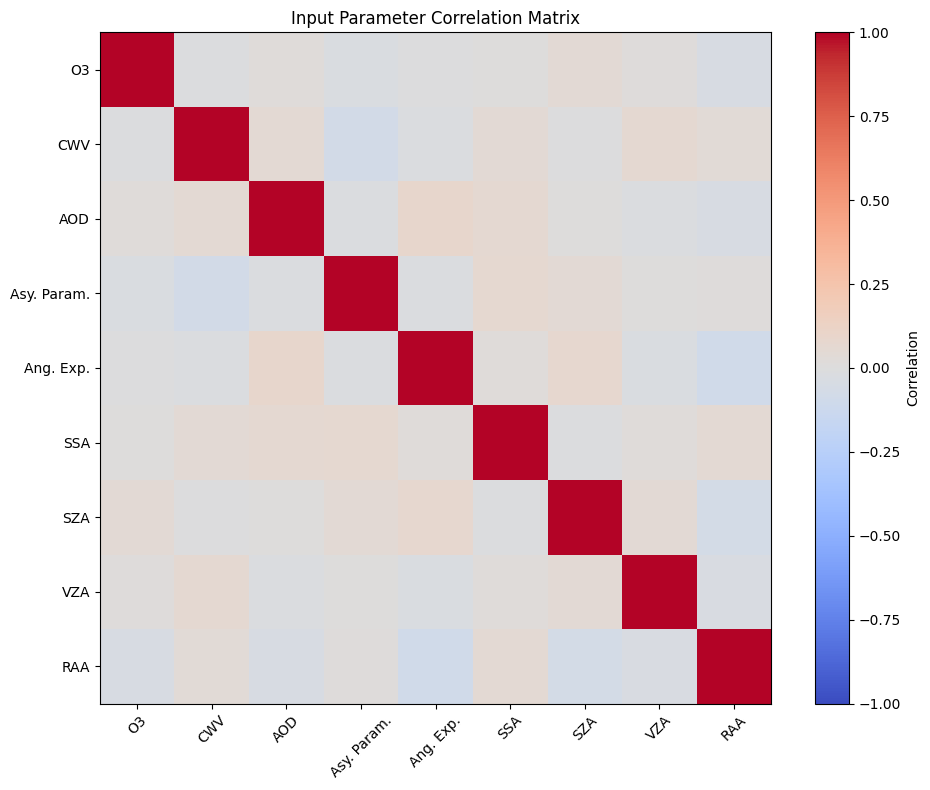

In [8]:
corr = pd.DataFrame(X, columns=globals.param_names_plots_abb).corr()

print("Correlation matrix:\n", corr)

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(globals.param_names_plots_abb)), globals.param_names_plots_abb, rotation=45)
plt.yticks(range(len(globals.param_names_plots_abb)), globals.param_names_plots_abb)

plt.title("Input Parameter Correlation Matrix")
plt.tight_layout()
plt.show()

Correlations between different input parameters are all around 0.

#### Outputs Analysis

In [9]:
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))
print("Y reshaped:", Y_resh.shape)

Y reshaped: (500, 6, 4205)


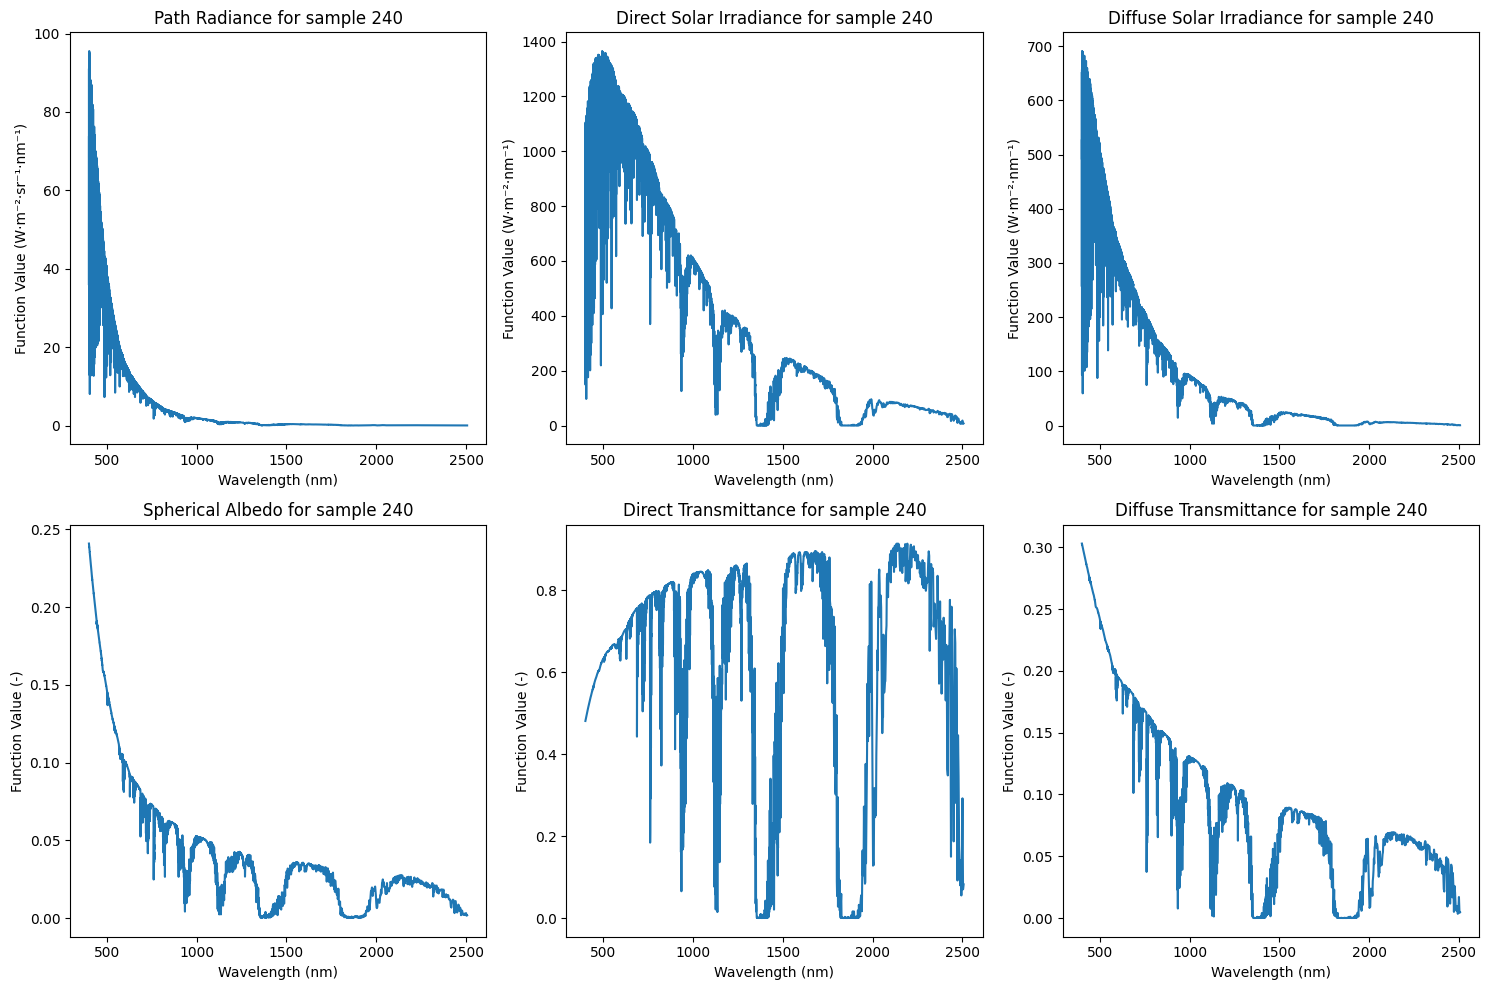

In [10]:
# visualize outputs for a random sample in different subplots
sample_idx = np.random.randint(Y_resh.shape[0])
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i+1)
    plt.plot(wavelengths, Y_resh[sample_idx, i, :])
    plt.title(f"{globals.function_names_plots[i]} for sample {sample_idx}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
plt.tight_layout()
plt.show()

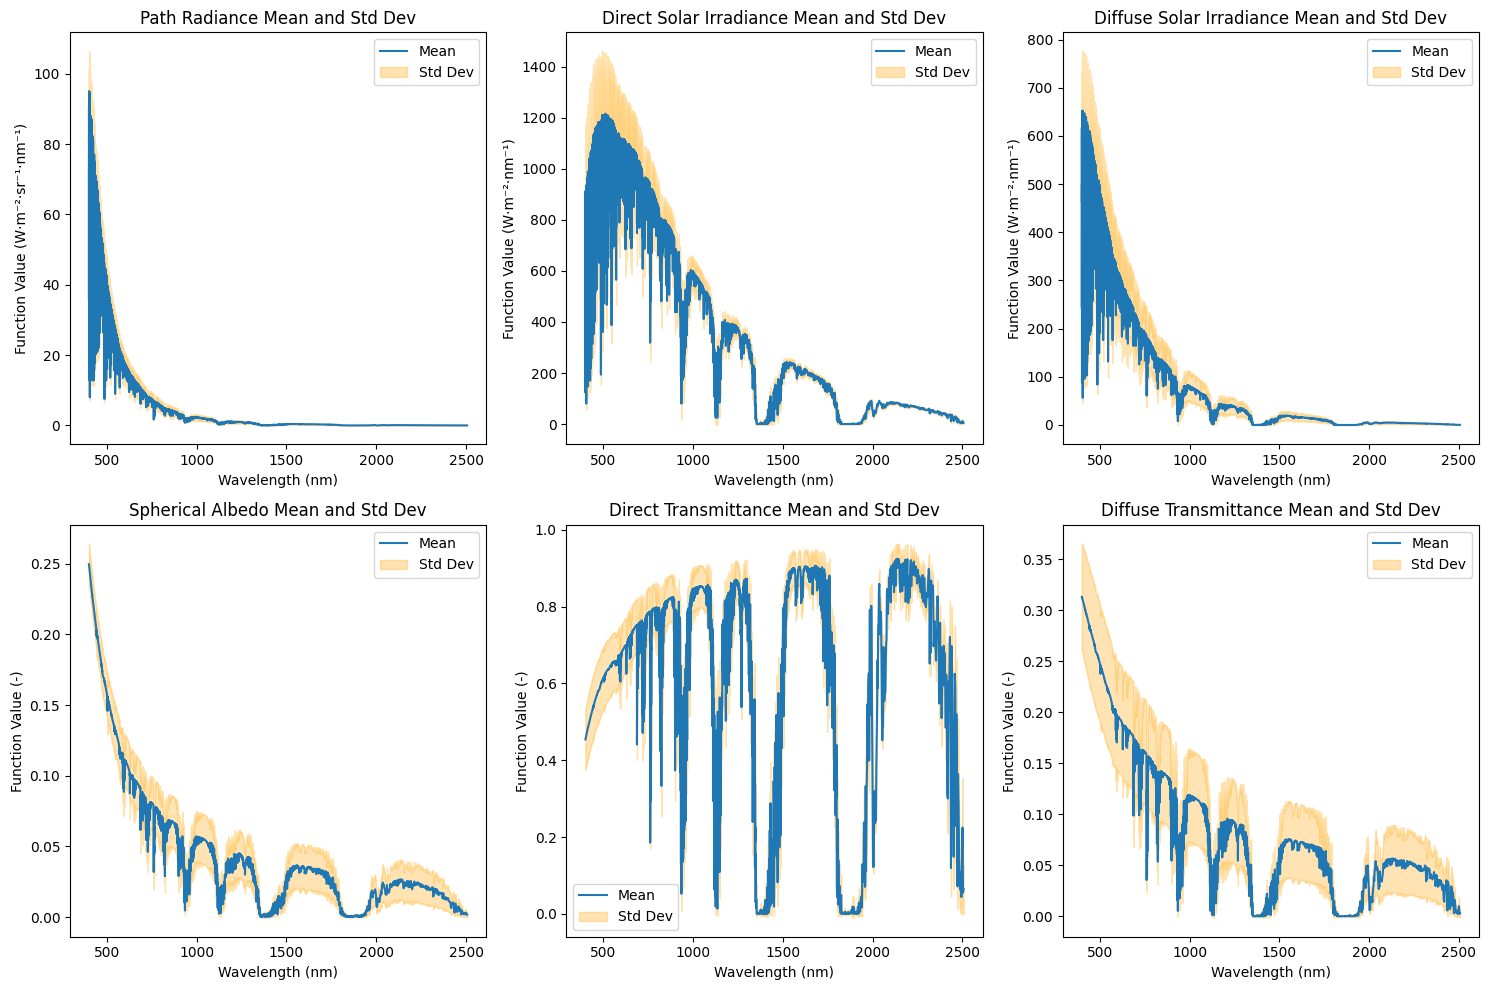

In [11]:
# visualize the mean and standard deviation band of the six functions for all outputs
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i+1)
    mean_func = np.mean(Y_resh[:, i, :], axis=0)
    std_func = np.std(Y_resh[:, i, :], axis=0)
    plt.plot(wavelengths, mean_func, label="Mean")
    plt.fill_between(wavelengths, mean_func - std_func, mean_func + std_func, color="orange", alpha=0.3, label="Std Dev")
    plt.title(f"{globals.function_names_plots[i]} Mean and Std Dev")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()
plt.tight_layout()
plt.show()

Correlation between output functions:
 [[ 1.      0.4844  0.9042  0.9225 -0.2214  0.808 ]
 [ 0.4844  1.      0.6361  0.5397  0.3282  0.511 ]
 [ 0.9042  0.6361  1.      0.8989 -0.1521  0.9143]
 [ 0.9225  0.5397  0.8989  1.     -0.1033  0.9291]
 [-0.2214  0.3282 -0.1521 -0.1033  1.     -0.0617]
 [ 0.808   0.511   0.9143  0.9291 -0.0617  1.    ]]


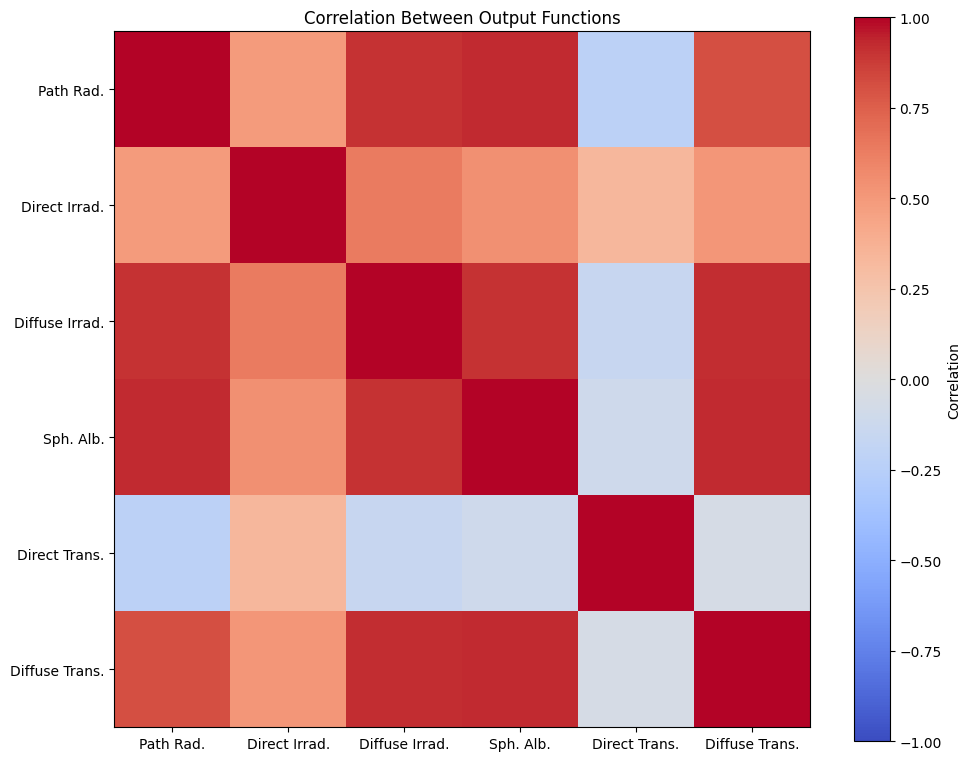

In [ ]:
# explore correlation between the six output functions across all samples and wavelengths

# reshape to (6, n_samples * n_wavelengths)
Y_flat = Y_resh.transpose(1, 0, 2).reshape(6, -1)

corr_outputs = np.corrcoef(Y_flat)

print("Correlation between output functions:\n", corr_outputs)

plt.figure(figsize=(10, 8))
plt.imshow(corr_outputs, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(6), [f"{globals.function_names_plots_abb[i]}" for i in range(6)])
plt.yticks(range(6), [f"{globals.function_names_plots_abb[i]}" for i in range(6)])

plt.title("Correlation Between Output Functions")
plt.tight_layout()
plt.show()

Path Radiance: remove 4191 / 4205 wavelengths


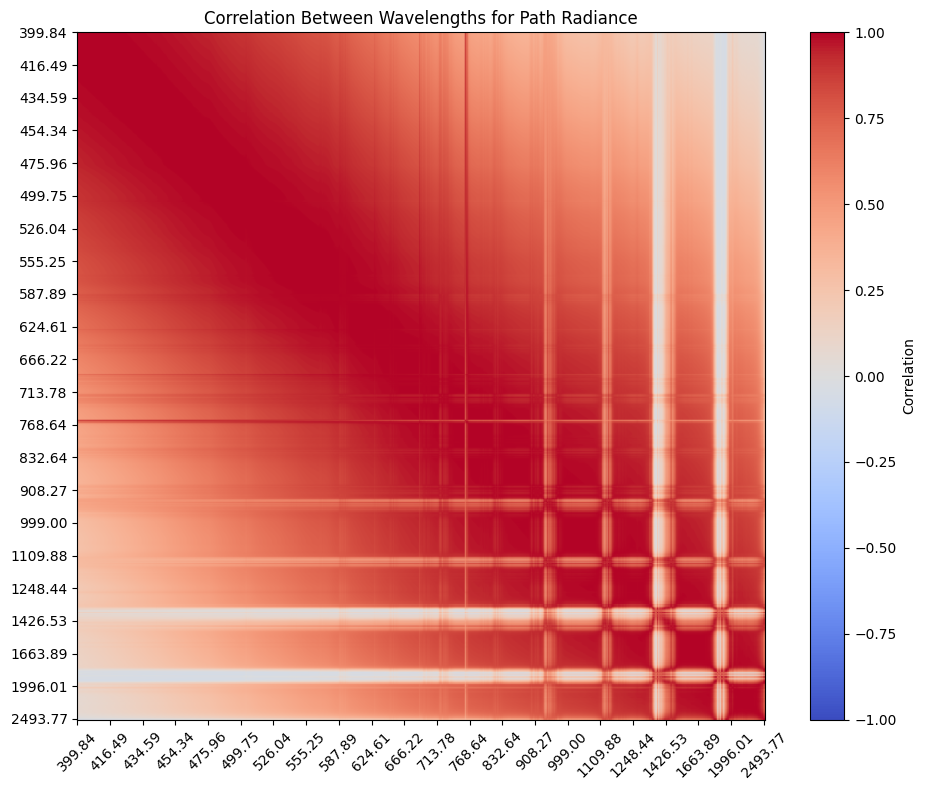

Direct Solar Irradiance: remove 4203 / 4205 wavelengths


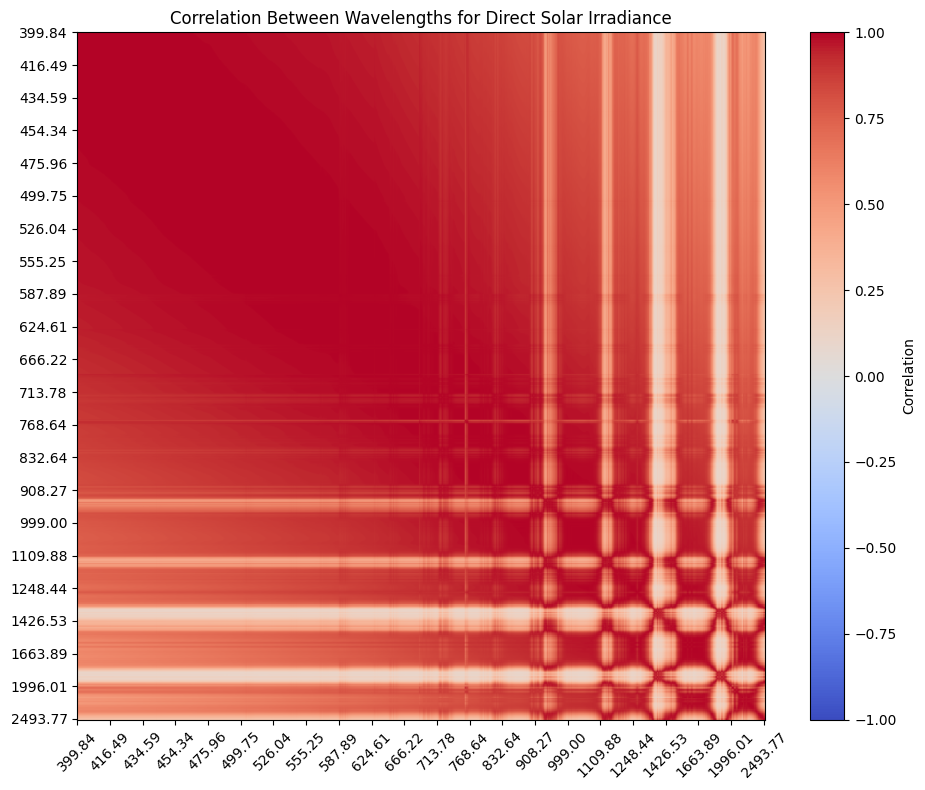

Diffuse Solar Irradiance: remove 4200 / 4205 wavelengths


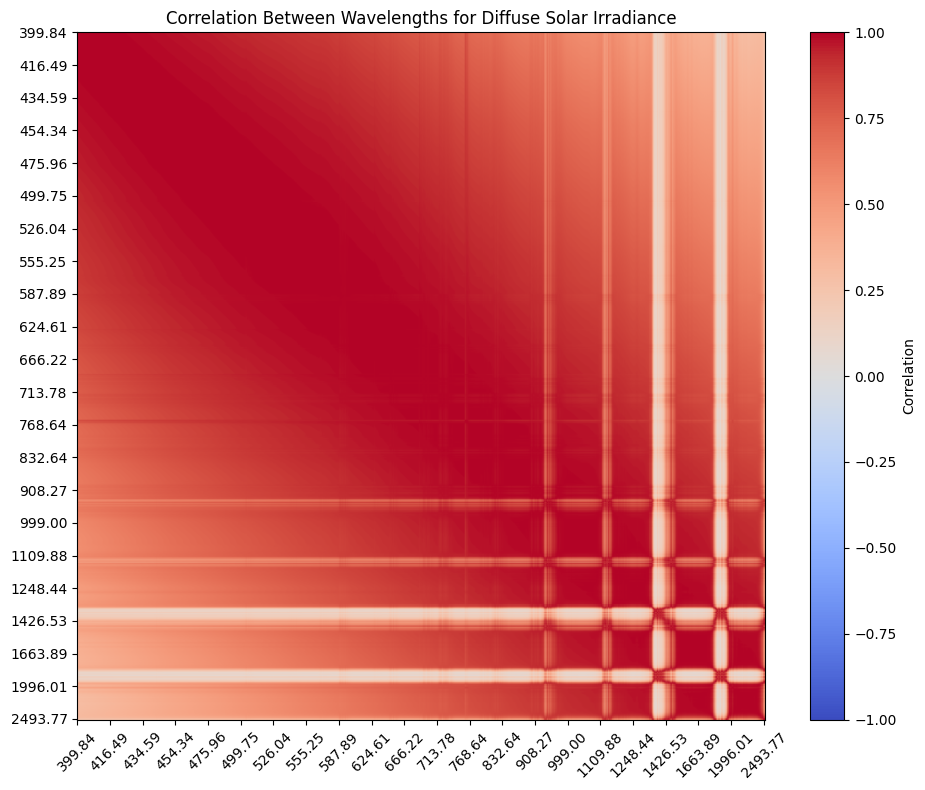

Spherical Albedo: remove 4180 / 4205 wavelengths


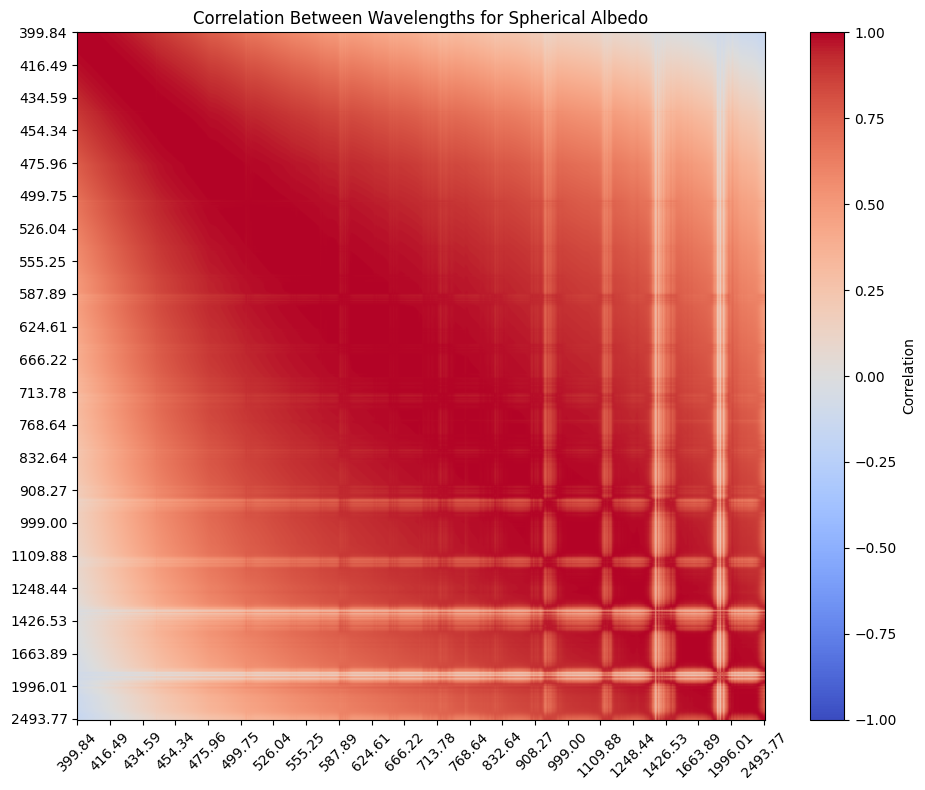

Direct Transmittance: remove 4204 / 4205 wavelengths


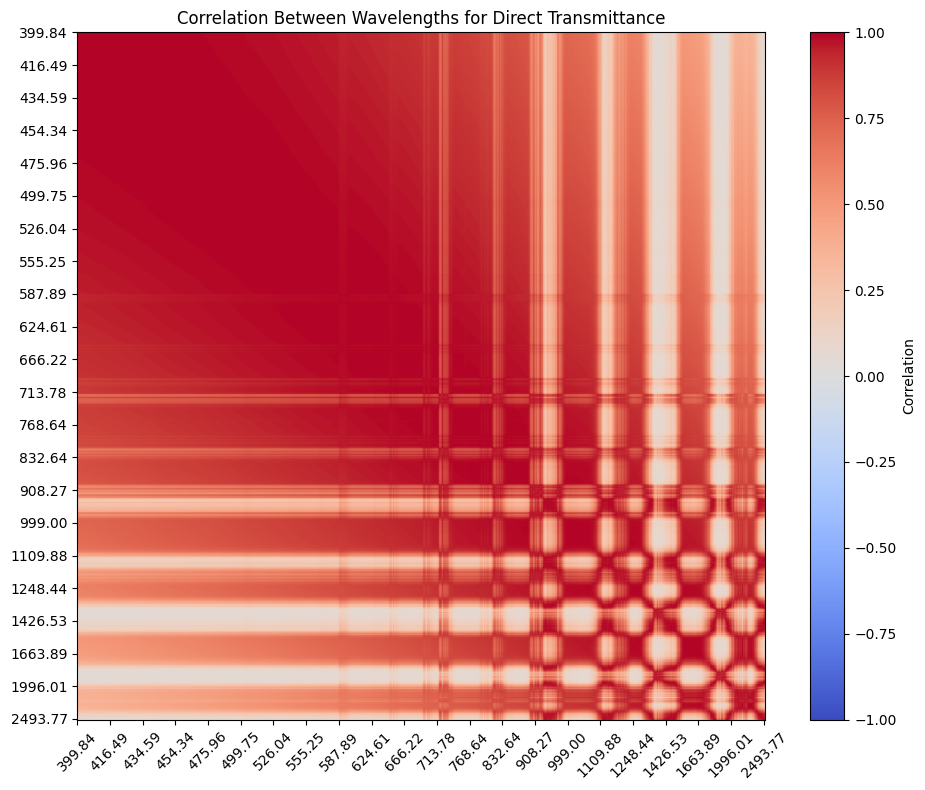

Diffuse Transmittance: remove 4170 / 4205 wavelengths


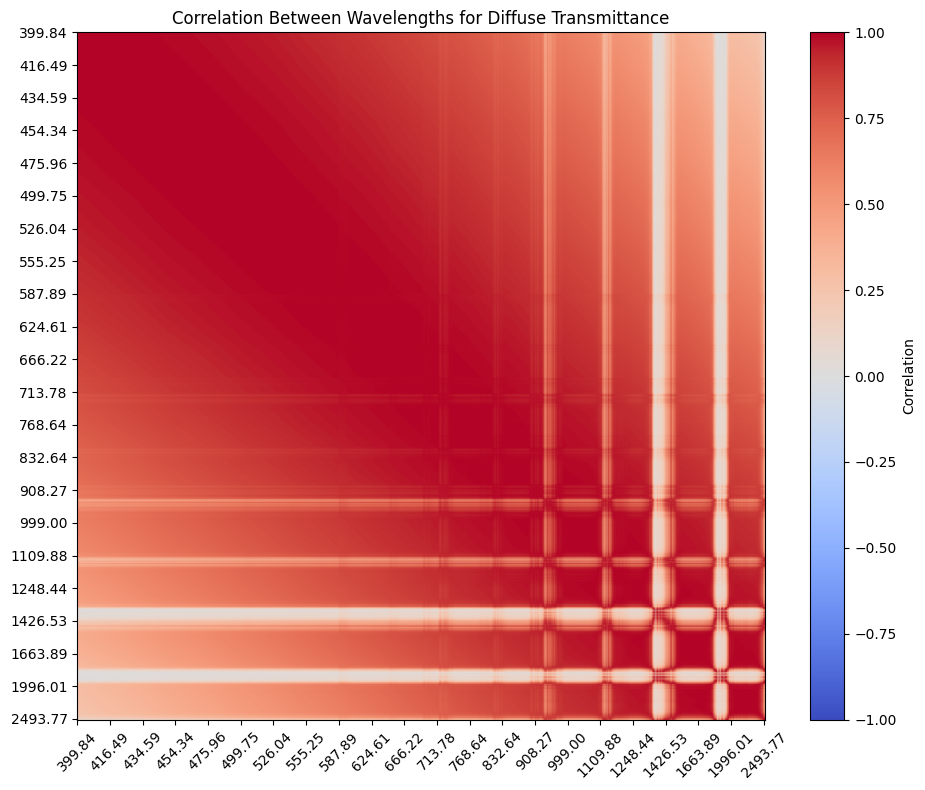

In [ ]:
# explore correlation between wavelengths for each function across all samples
corr_wavelengths_to_remove = []
corr_wavelengths_to_keep = []
corr_threshold = 0.95
for i in range(globals.N_FUNCTIONS):

    Y_func = Y_resh[:, i, :]  # shape (n_samples, n_wavelengths)
    corr_wavelengths = np.corrcoef(Y_func.T)  # shape (n_wavelengths, n_wavelengths)

    # removal of highly correlated bands
    upper_tri = np.triu(np.abs(corr_wavelengths), k=1) # use only upper triangle to avoid duplicate pairs
    to_remove = set()

    for col in range(upper_tri.shape[1]):

        # if current wavelength is already removed, skip
        if col in to_remove:
            continue

        # find wavelengths highly correlated with current one
        highly_corr = np.where(upper_tri[:, col] > corr_threshold)[0]

        # remove correlated wavelengths (keep first occurrence)
        to_remove.update(highly_corr)

    to_remove = sorted(list(to_remove))
    to_keep = sorted(set(range(Y_func.shape[1])) - set(to_remove))
    corr_wavelengths_to_remove.append(to_remove)
    corr_wavelengths_to_keep.append(to_keep)

    print(f"{globals.function_names_plots[i]}: remove {len(to_remove)} / {Y_func.shape[1]} wavelengths")

    plt.figure(figsize=(10, 8))
    plt.imshow(corr_wavelengths, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    step = 200
    ticks = np.arange(0, len(wavelengths), step)
    plt.xticks(ticks, [f"{w:.2f}" for w in wavelengths[::step]], rotation=45)
    plt.yticks(ticks, [f"{w:.2f}" for w in wavelengths[::step]])

    plt.title(f"Correlation Between Wavelengths for {globals.function_names_plots[i]}")
    plt.tight_layout()
    plt.show()

In [ ]:
Y_resh_reduced = []

for i in range(globals.N_FUNCTIONS):

    remove_idx = corr_wavelengths_to_remove[i]

    # wavelengths to keep
    keep_idx = np.setdiff1d(
        np.arange(Y_resh.shape[2]),
        remove_idx
    )

    # reduced data for this function
    # shape: (n_samples, n_remaining_wavelengths)
    Y_func_reduced = Y_resh[:, i, keep_idx]

    Y_resh_reduced.append(Y_func_reduced)

print("Original number of wavelengths:", Y_resh.shape[2])
for i in range(globals.N_FUNCTIONS):
    print(f"{globals.function_names_plots[i]}: kept number of wavelengths:", Y_resh_reduced[i].shape[1])

Original number of wavelengths: 4205
Path Radiance: kept number of wavelengths: 14
Direct Solar Irradiance: kept number of wavelengths: 2
Diffuse Solar Irradiance: kept number of wavelengths: 5
Spherical Albedo: kept number of wavelengths: 25
Direct Transmittance: kept number of wavelengths: 1
Diffuse Transmittance: kept number of wavelengths: 35


In [16]:
global_keep = sorted(set.union(*[set(keep) for keep in corr_wavelengths_to_keep]))

Y_resh_reduced = Y_resh[:, :, global_keep]

print("Original shape:", Y_resh.shape)
print("Reduced shape:", Y_resh_reduced.shape)

Original shape: (500, 6, 4205)
Reduced shape: (500, 6, 46)


#### Train-Val split

In [12]:
# first split: train (80%) and temp (20%)
X_tr, X_temp, Y_tr, Y_temp = train_test_split(X, Y_resh, test_size=0.2, shuffle=True, random_state=42)

# second split: validation (10%) and test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=True, random_state=42)

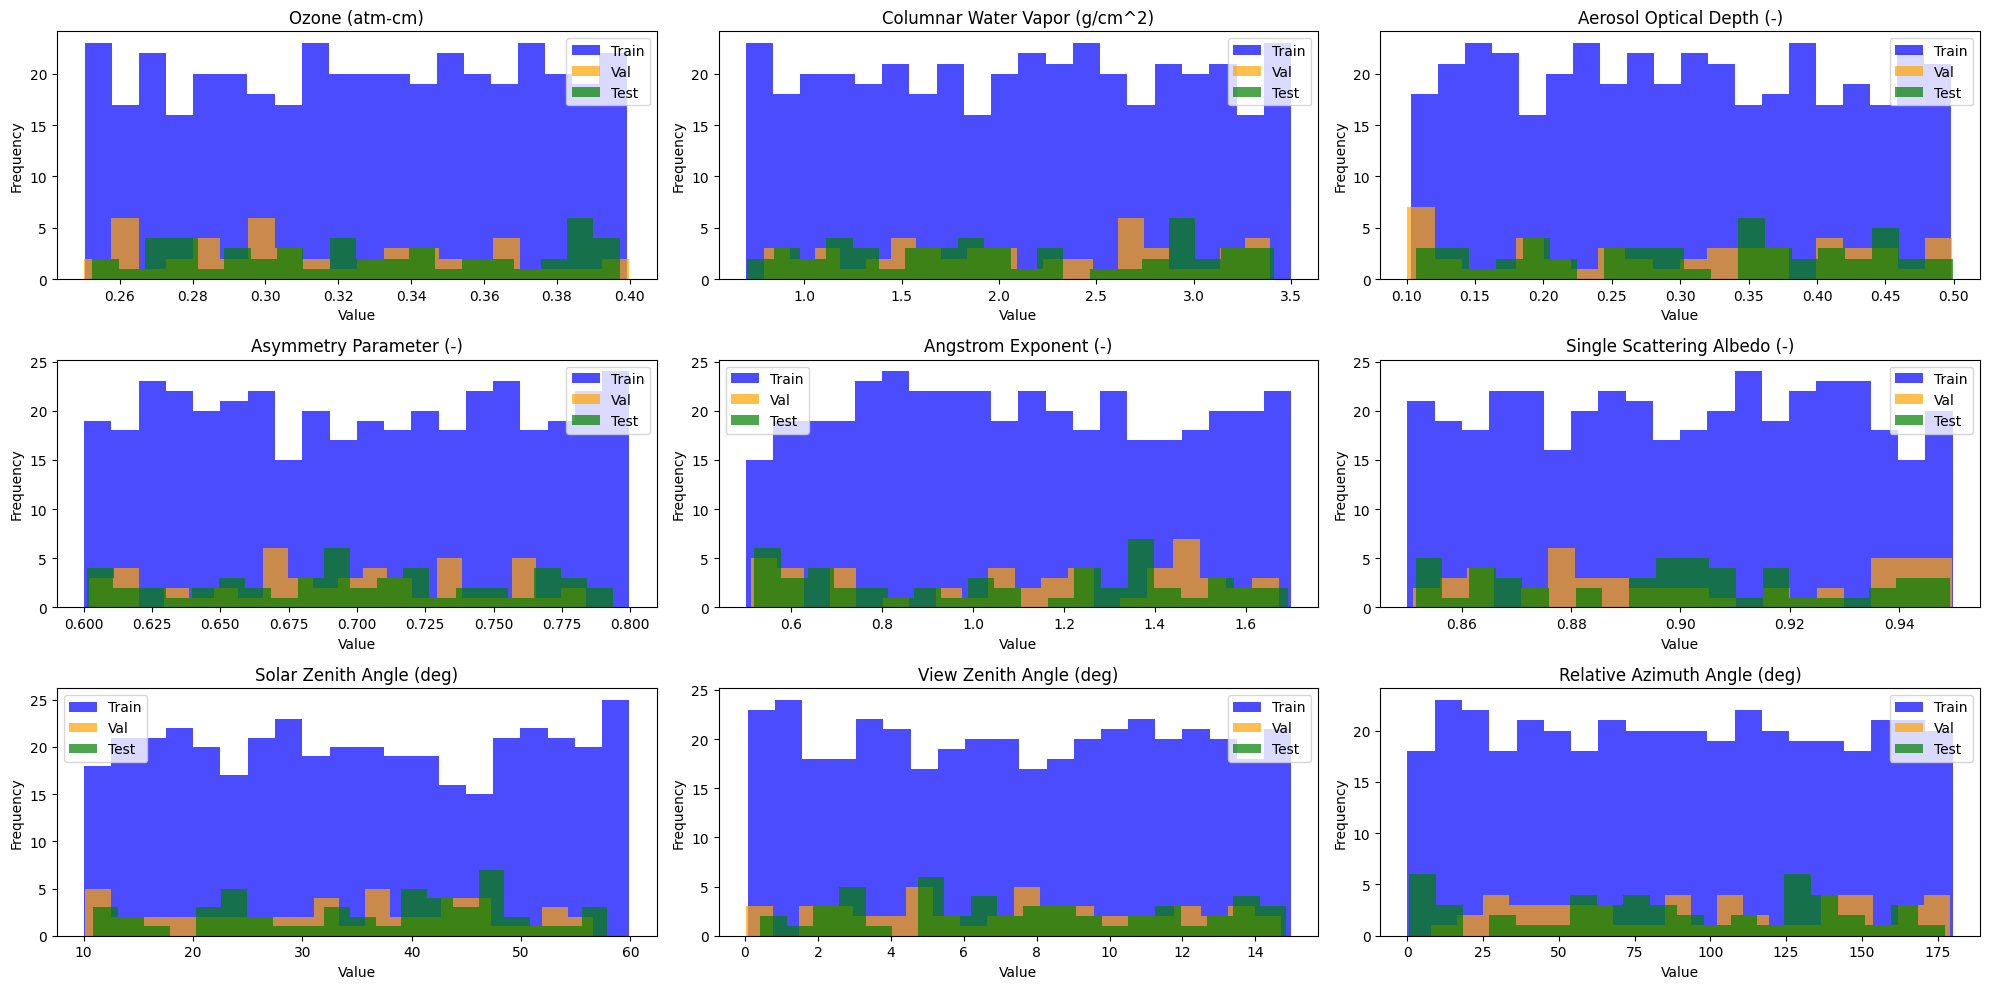

In [13]:
# overlay histograms of input train and val parameters to check if they have similar distributions
plt.figure(figsize=(20, 10))
for i in range(X_tr.shape[1]):
    plt.subplot(3, 3, i+1)
    plt.hist(X_tr[:, i], bins=20, color="blue", alpha=0.7, label="Train")
    plt.hist(X_val[:, i], bins=20, color="orange", alpha=0.7, label="Val")
    plt.hist(X_test[:, i], bins=20, color="green", alpha=0.7, label="Test")
    plt.title(globals.param_names_plots[i])
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
plt.tight_layout()
plt.show()

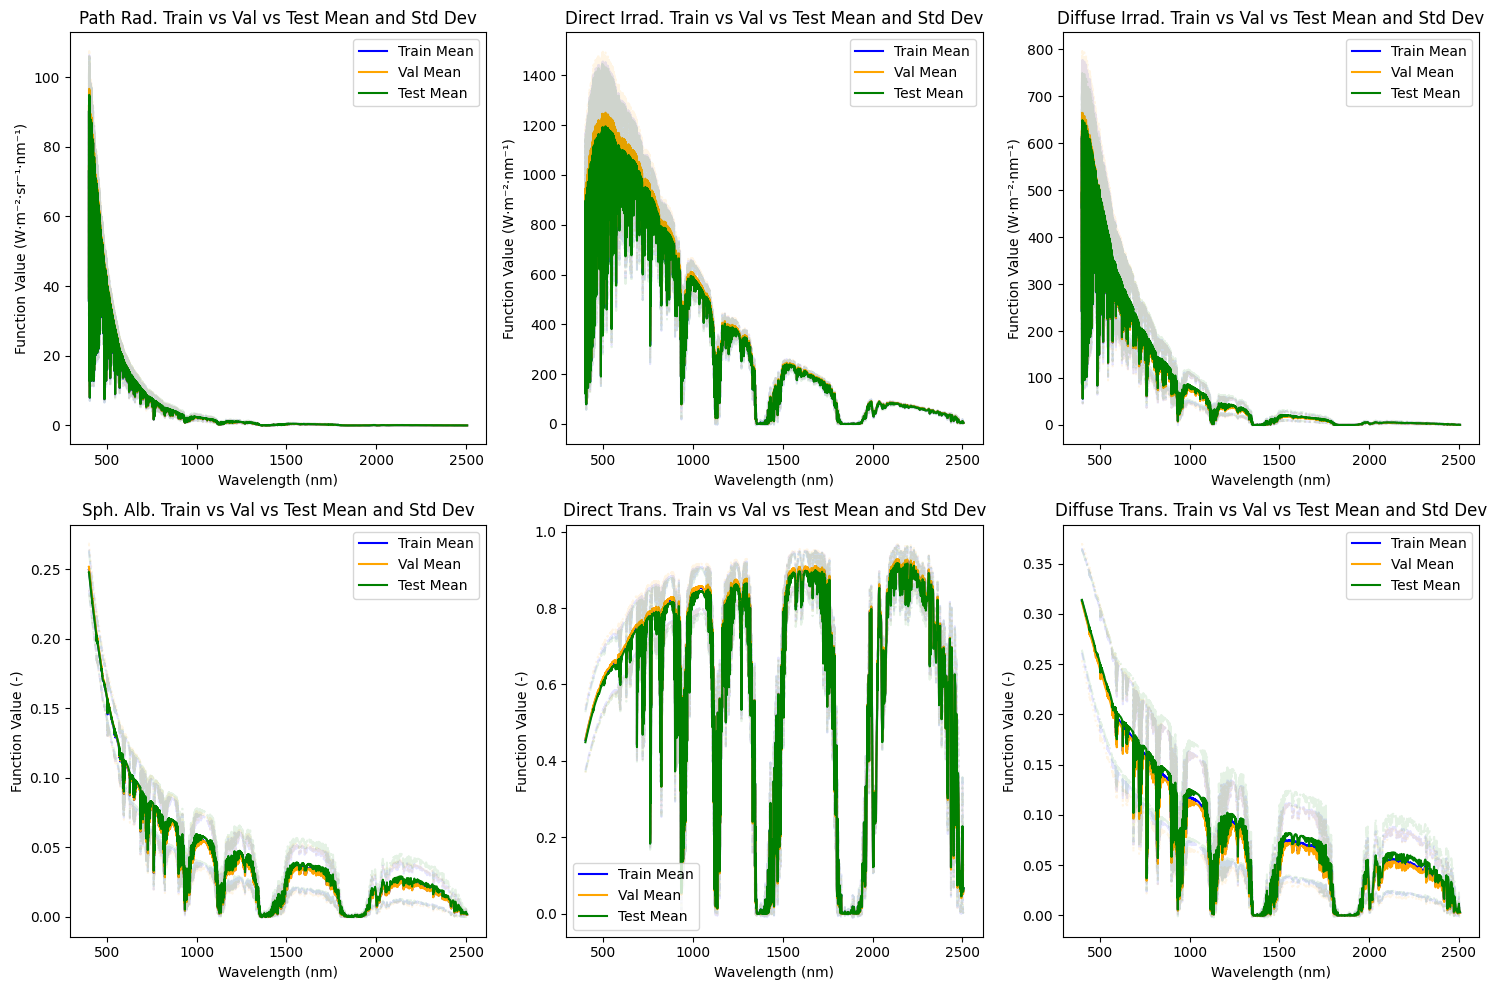

In [14]:
# overlay mean and std dev of train and val outputs to check if they have similar distributions
plt.figure(figsize=(15, 10))
for i in range(Y_tr.shape[1]):
    plt.subplot(2, 3, i+1)
    mean_tr = np.mean(Y_tr[:, i, :], axis=0)
    std_tr = np.std(Y_tr[:, i, :], axis=0)
    mean_val = np.mean(Y_val[:, i, :], axis=0)
    std_val = np.std(Y_val[:, i, :], axis=0)
    mean_test = np.mean(Y_test[:, i, :], axis=0)
    std_test = np.std(Y_test[:, i, :], axis=0)
    
    plt.plot(wavelengths, mean_tr, label="Train Mean", color="blue")
    plt.plot(wavelengths, mean_tr + std_tr, color="blue", linestyle="--", alpha=0.1)
    plt.plot(wavelengths, mean_tr - std_tr, color="blue", linestyle="--", alpha=0.1)
    
    plt.plot(wavelengths, mean_val, label="Val Mean", color="orange")
    plt.plot(wavelengths, mean_val + std_val, color="orange", linestyle=":", alpha=0.1)
    plt.plot(wavelengths, mean_val - std_val, color="orange", linestyle=":", alpha=0.1)

    plt.plot(wavelengths, mean_test, label="Test Mean", color="green")
    plt.plot(wavelengths, mean_test + std_test, color="green", linestyle="-.", alpha=0.1)
    plt.plot(wavelengths, mean_test - std_test, color="green", linestyle="-.", alpha=0.1)
    
    plt.title(f"{globals.function_names_plots_abb[i]} Train vs Val vs Test Mean and Std Dev")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()
plt.tight_layout()
plt.show()